In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

# load, read and store original network


In [14]:
edges = pd.read_csv('edges.csv', comment='#', names=['source', 'target'])
G = nx.Graph()
G = nx.from_pandas_edgelist(edges, source='source', target='target')

In [48]:
print(G.number_of_nodes())
print(G.number_of_edges())

623766
15699276


In [16]:
np.mean([k for n, k in G.degree()])

np.float64(50.33706870845798)

In [17]:
density = nx.density(G)
print(density)

8.069877070444475e-05


In [18]:
components = list(nx.connected_components(G))
print(f'number of connected components: {len(components)}')

number of connected components: 8492


In [19]:
giant_component = max(components, key=len)

print(f'size of giant component: {len(giant_component)}')

percentage = (len(giant_component) / G.number_of_nodes()) * 100
print(percentage)

size of giant component: 601213
96.38438132248311


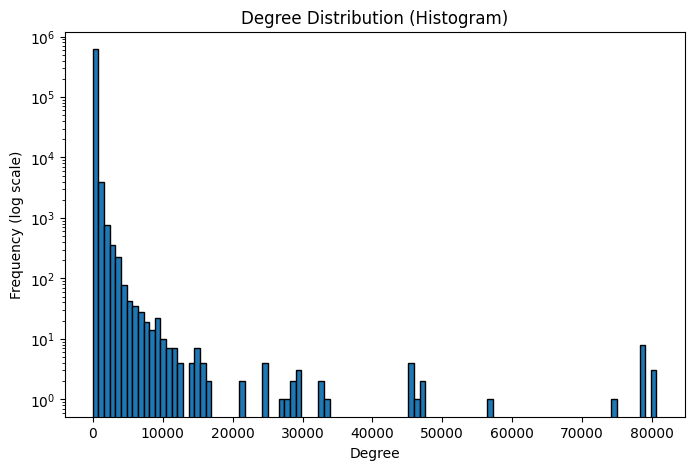

In [20]:
degree_values = [d for _, d in G.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=100, edgecolor='black', log=True)  # log scale helps large range
plt.xlabel("Degree")
plt.ylabel("Frequency (log scale)")
plt.title("Degree Distribution (Histogram)")
plt.show()

In [21]:
# Store original network metrics
original_metrics = {
    'nodes': G.number_of_nodes(),
    'edges': G.number_of_edges(),
    'density': nx.density(G),
    'avg_degree': np.mean([k for n, k in G.degree()]),
    'num_components': len(list(nx.connected_components(G))),
    'giant_component_size': len(max(nx.connected_components(G), key=len))
}

print("Original Network Metrics:")
for key, value in original_metrics.items():
    print(f"  {key}: {value}")

Original Network Metrics:
  nodes: 623766
  edges: 15699276
  density: 8.069877070444475e-05
  avg_degree: 50.33706870845798
  num_components: 8492
  giant_component_size: 601213


In [ ]:
# compute and sort degrees
degree_dict = dict(G.degree())
sorted_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)


attack_nodes = sorted_nodes[:1000] # change 100 to whatever size attack u want 

attack_nodes[:10] 
# if not [121862, 121863, 121861, 57588, 57592, 57594, 57589, 57593, 57595, 57590]
# then something wrong :D

[121862, 121863, 121861, 57588, 57592, 57594, 57589, 57593, 57595, 57590]

In [42]:
G_attacked = G.copy()
G_attacked.remove_nodes_from(attack_nodes)

In [43]:
original_lcc = len(max(nx.connected_components(G), key=len))
attacked_lcc = len(max(nx.connected_components(G_attacked), key=len))

original_lcc, attacked_lcc

(601213, 508088)

C:\Users\marti\AppData\Local\Temp\ipykernel_6260\2880105621.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


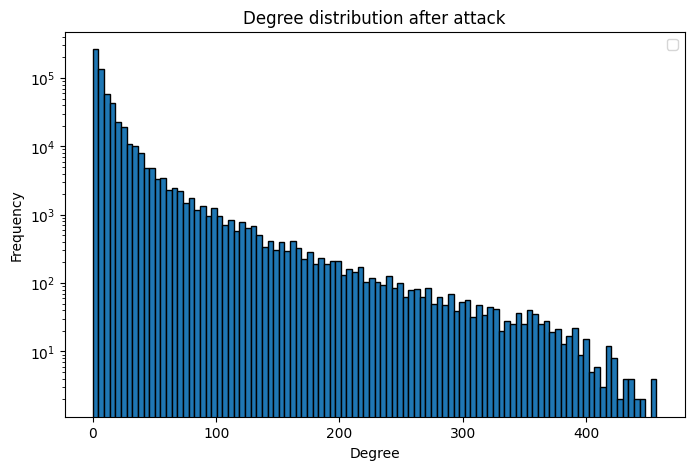

In [ ]:

# after attack dd 
plt.figure(figsize=(8,5))
plt.hist([d for _, d in G_attacked.degree()], bins=100, edgecolor='black', log=True)

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.legend()
plt.title("Degree distribution after attack")
plt.show()

In [49]:
attacked_metrics = {
    'nodes': G_attacked.number_of_nodes(),
    'edges': G_attacked.number_of_edges(),
    'density': nx.density(G_attacked),
    'avg_degree': np.mean([k for n, k in G_attacked.degree()]),
    'num_components': len(list(nx.connected_components(G_attacked))),
    'giant_component_size': len(max(nx.connected_components(G_attacked), key=len))
}

print("Attacked Network Metrics:")
for key, value in attacked_metrics.items():
    print(f"  {key}: {value}")

print("Original Network Metrics:")
for key, value in original_metrics.items():
    print(f"  {key}: {value}")

Attacked Network Metrics:
  nodes: 613766
  edges: 4339757
  density: 2.304042374898513e-05
  avg_degree: 14.141405682295858
  num_components: 60769
  giant_component_size: 508088
Original Network Metrics:
  nodes: 623766
  edges: 15699276
  density: 8.069877070444475e-05
  avg_degree: 50.33706870845798
  num_components: 8492
  giant_component_size: 601213
